In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [7]:
# step 1: load dataset
github_users = pd.read_csv("C:/Users/ADMIN/Desktop/MSC APPLIED STATISTICS/minor project/github.csv",engine='python')
github_users

,Unnamed: 0,username,name,joining_year,repositories,last_year_contributions,achievements_num,stars,followers,followings,...,works_for,status,location,language,sorting_type,gender_pronoun,social_link,social_platform,description,sorting type
0,0,SumithSPrince,Sumith S,2021,1.0,2.0,0.0,0.0,0.0,1.0,...,NaN,NaN,"Bangalore, India",Java,NaN,he/him,NaN,NaN,Hello 👋\n\nGreat you visited my profile!\n\nI'...,Most recently joined
1,1,infysumanta,Sumanta Kabiraj,2018,445.0,623.0,5.0,87.0,9.0,38.0,...,NaN,Focusing,"Kolkata, India",Java,NaN,NaN,https://sumantakabiraj.com,X@infysumanta,Sculpting the digital frontier with a mastery ...,Most repositories
2,2,codingwithkrish,Krish Gupta,2021,37.0,204.0,6.0,9.0,6.0,8.0,...,Synkrama,NaN,India,Java,NaN,NaN,http://krishgupta.com,NaN,I am a B.Tech Professional students from Vishw...,Most followers
3,3,anirbanbose401,ANIRBAN BOSE,2023,3.0,2.0,0.0,0.0,0.0,3.0,...,Institute of Technical Education and Research,NaN,India,Java,NaN,he/him,https://www.soa.ac.in/iter,LinkedInin/anirban-bose-4a238b245,I've always been interested in programming. So...,Most recently joined
4,4,neilrehani101,Neil Rehani,2021,29.0,6.0,0.0,0.0,0.0,3.0,...,NaN,NaN,India,Python,NaN,he/him,NaN,NaN,I am a keen learner and want to explore nearly...,Fewest followers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10117,10065,EzhilarasanVezhavendan,EZHILARASAN VEZHAVENDAN,2023,11.0,212.0,3.0,0.0,0.0,NaN,...,NaN,NaN,"Tamil Nadu, India",Python,NaN,he/him,NaN,LinkedInin/ezhilarasan-vezhavendan-b1886024a,I am a highly motivated and Enthusiastic fresh...,Fewest followers
10118,10066,iammohib,Mohd Mohibuddin,2020,7.0,1423.0,4.0,1.0,0.0,NaN,...,NaN,NaN,India,JavaScript,NaN,he/him,http://mohib.co/,LinkedInin/iammohib,Hello there! I'm a highly skilled Full Stack D...,Most followers
10119,10067,jha-hitesh,Hitesh Jha,2017,17.0,5.0,2.0,55.0,2.0,3.0,...,Fynd (Shopsense retails Pvt Ltd),in a full time job,"Mumbai, India",Python,NaN,NaN,NaN,NaN,A python developer with additional interest in...,Least recently joined
10120,10068,therohitdas,Rohit Das,2018,20.0,278.0,7.0,290.0,22.0,38.0,...,@booleanbridge,"intermediate dev, plagued by ai","Uttarpara, India",Python,NaN,he/him,https://theRohitDas.com,X@theRohitDas,building a WFH home business,Best match


In [58]:
# step 2: Data Exploration
print("first 5 rows of data set:")
print(github_users.head())

print("\nData set info:")
print(github_users.info())

print("\nmissing values:")
print(github_users.isnull().sum())

first 5 rows of data set:
          username             name  joining_year  repositories  \
0    SumithSPrince         Sumith S        2021.0           1.0   
1      infysumanta  Sumanta Kabiraj        2018.0         445.0   
2  codingwithkrish      Krish Gupta        2021.0          37.0   
3   anirbanbose401     ANIRBAN BOSE        2023.0           3.0   
4    neilrehani101      Neil Rehani        2021.0          29.0   

   last_year_contributions  achievements_num  stars  followers  followings  \
0                      2.0               0.0    0.0        0.0         1.0   
1                    623.0               5.0   87.0        9.0        38.0   
2                    204.0               6.0    9.0        6.0         8.0   
3                      2.0               0.0    0.0        0.0         3.0   
4                      6.0               0.0    0.0        0.0         3.0   

  has_readme          location language  sorting_type  \
0      False  Bangalore, India     Java      

In [15]:
github_users.describe()

,joining_year,repositories,last_year_contributions,achievements_num,stars,followers,followings,sorting_type
count,10070.000000,10070.000000,10070.000000,10070.000000,10070.000000,10070.000000,7173.000000,0.0
mean,2019.346475,21.636147,93.656802,1.118868,20.952135,11.181033,14.548864,NaN
std,3.174348,47.164044,296.274967,1.739766,102.929111,120.206086,112.150389,NaN
min,1969.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,2017.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
50%,2020.000000,11.000000,6.000000,0.000000,2.000000,1.000000,3.000000,NaN
75%,2022.000000,27.000000,55.000000,2.000000,10.000000,6.000000,10.000000,NaN
max,2024.000000,3100.000000,8291.000000,15.000000,3400.000000,8800.000000,7100.000000,NaN


In [57]:
github_users['language'].count()
github_users['language'].value_counts
print(df['language'].value_counts())

language
Python    3746
Java      2947
Name: count, dtype: int64


In [17]:
# step 3: filtering python and java developers
upd_data = github_users[github_users['language'].isin(['Python','Java'])].copy()
upd_data


,username,name,joining_year,repositories,last_year_contributions,achievements_num,stars,followers,followings,has_readme,location,language,sorting_type,social_link,social_platform,description,sorting_type
0,SumithSPrince,Sumith S,2021.0,1.0,2.0,0.0,0.0,0.0,1.0,False,"Bangalore, India",Java,NaN,NaN,NaN,Hello 👋\n\nGreat you visited my profile!\n\nI'...,Most recently joined
1,infysumanta,Sumanta Kabiraj,2018.0,445.0,623.0,5.0,87.0,9.0,38.0,True,"Kolkata, India",Java,NaN,https://sumantakabiraj.com,X@infysumanta,Sculpting the digital frontier with a mastery ...,Most repositories
2,codingwithkrish,Krish Gupta,2021.0,37.0,204.0,6.0,9.0,6.0,8.0,True,India,Java,NaN,http://krishgupta.com,NaN,I am a B.Tech Professional students from Vishw...,Most followers
3,anirbanbose401,ANIRBAN BOSE,2023.0,3.0,2.0,0.0,0.0,0.0,3.0,False,India,Java,NaN,https://www.soa.ac.in/iter,LinkedInin/anirban-bose-4a238b245,I've always been interested in programming. So...,Most recently joined
4,neilrehani101,Neil Rehani,2021.0,29.0,6.0,0.0,0.0,0.0,3.0,False,India,Python,NaN,NaN,NaN,I am a keen learner and want to explore nearly...,Fewest followers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10087,sivasvcop,G. Siva Kumar,2023.0,4.0,1.0,0.0,1.0,1.0,5.0,True,"Andhra Pradesh, India",Python,NaN,NaN,LinkedInin/g-siva-kumar-7172188b,I am a motivated learner looking to enter the ...,Most recently joined
10090,code-arpit,Arpit Jain,2021.0,30.0,711.0,7.0,5.0,5.0,8.0,True,"Delhi,India",Python,NaN,NaN,NaN,I am a python developer,Most repositories
10092,EzhilarasanVezhavendan,EZHILARASAN VEZHAVENDAN,2023.0,11.0,212.0,3.0,0.0,0.0,NaN,False,"Tamil Nadu, India",Python,NaN,NaN,LinkedInin/ezhilarasan-vezhavendan-b1886024a,I am a highly motivated and Enthusiastic fresh...,Fewest followers
10094,jha-hitesh,Hitesh Jha,2017.0,17.0,5.0,2.0,55.0,2.0,3.0,False,"Mumbai, India",Python,NaN,NaN,NaN,A python developer with additional interest in...,Least recently joined


In [54]:
# step 4: comparing mean and variance
df = github_users[github_users['language'].isin(['Python', 'Java'])]
mean_values = df.groupby('language')[['stars', 'followers', 'repositories' ,'last_year_contributions', 'achievements_num']].mean()
variance_values = df.groupby('language')[['stars', 'followers', 'repositories', 'last_year_contributions', 'achievements_num']].var()
print(mean_values)
print()
print(variance_values)

              stars  followers  repositories  last_year_contributions  \
language                                                                
Java      19.257889   8.408890     20.538174                74.576858   
Python    21.687133  12.092365     20.889215                93.399359   

          achievements_num  
language                    
Java              1.077367  
Python            1.045649  

                 stars     followers  repositories  last_year_contributions  \
language                                                                      
Java      12628.215208   3382.078169    982.605721             60582.367733   
Python    10403.934665  24171.064898   3612.437657             73887.749148   

          achievements_num  
language                    
Java              2.681046  
Python            2.872949  


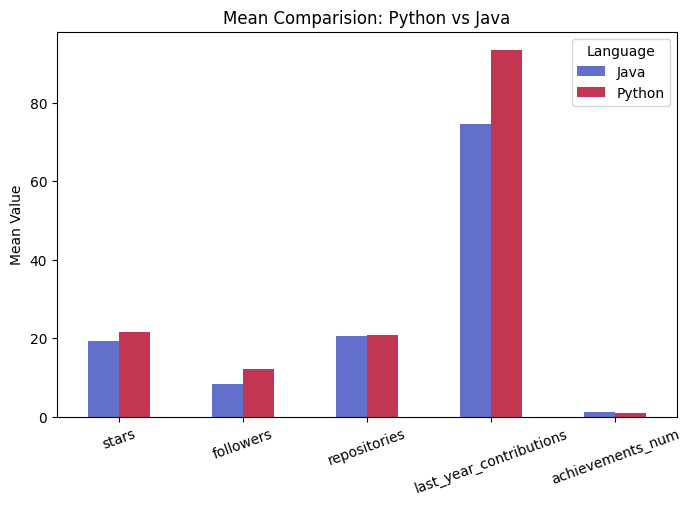

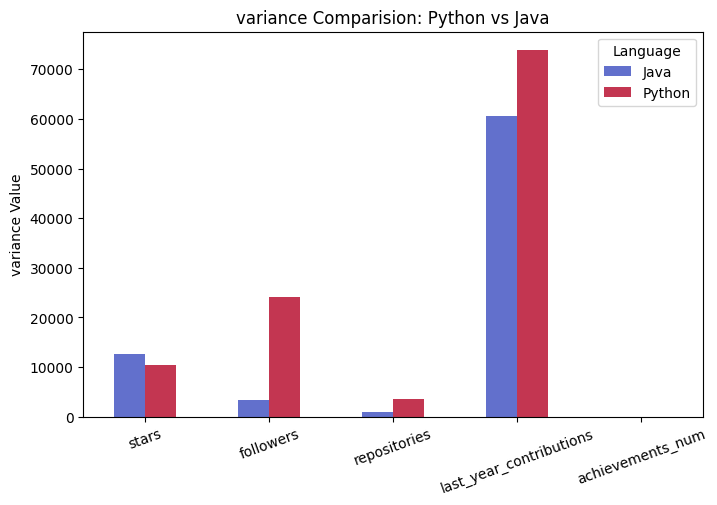

In [47]:
# step 5: visualizing the comparision of mean and variance
mean_values.T.plot(kind='bar', figsize=(8, 5), colormap='coolwarm', alpha=0.8)
plt.ylabel("Mean Value")
plt.title("Mean Comparision: Python vs Java")
plt.xticks(rotation=20)
plt.legend(title = "Language")
plt.show()
print(' ')
variance_values.T.plot(kind='bar', figsize=(8, 5), colormap='coolwarm', alpha=0.8)
plt.ylabel("variance Value")
plt.title("variance Comparision: Python vs Java")
plt.xticks(rotation=20)
plt.legend(title = "Language")
plt.show()


In [48]:
# step 6: calculating the popularity score
upd_data = upd_data.copy()
upd_data['popularity_score'] = (
    (0.3*upd_data['repositories'])+
    (0.3*upd_data['last_year_contributions'])+
    (0.2*upd_data['stars'])+
    (0.2*upd_data['followers'])
)
# now apply groupby
popularity_trend = upd_data.groupby(['joining_year', 'language'])['popularity_score'].mean().reset_index()

print(popularity_trend.head())      #check first few rows
    

   joining_year language  popularity_score
0        1969.0   Python         19.500000
1        2008.0   Python        591.066667
2        2009.0   Python        121.800000
3        2010.0     Java         17.887500
4        2010.0   Python         49.220000


language
Java      34.067866
Python    41.042472
Name: popularity_score, dtype: float64
 


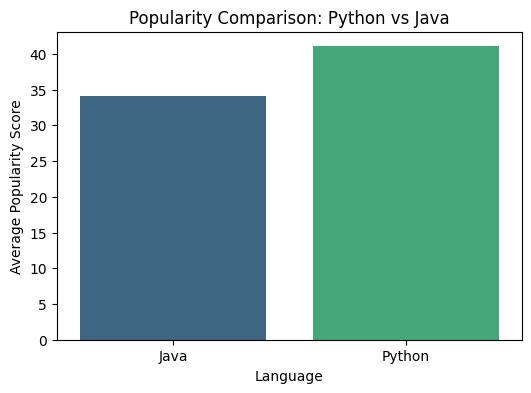

In [49]:
# step 7: comparing the popularity and plotting through barplot
popularity_comparison = upd_data.groupby('language')['popularity_score'].mean()
print(popularity_comparison)
print(' ')

# plot bar chart
plt.figure(figsize=(6,4))

sns.barplot(x=popularity_comparison.index,y=popularity_comparison.values,hue=popularity_comparison.index, palette='viridis')
plt.title("Popularity Comparison: Python vs Java")
plt.xlabel("Language")
plt.ylabel("Average Popularity Score")
plt.show()

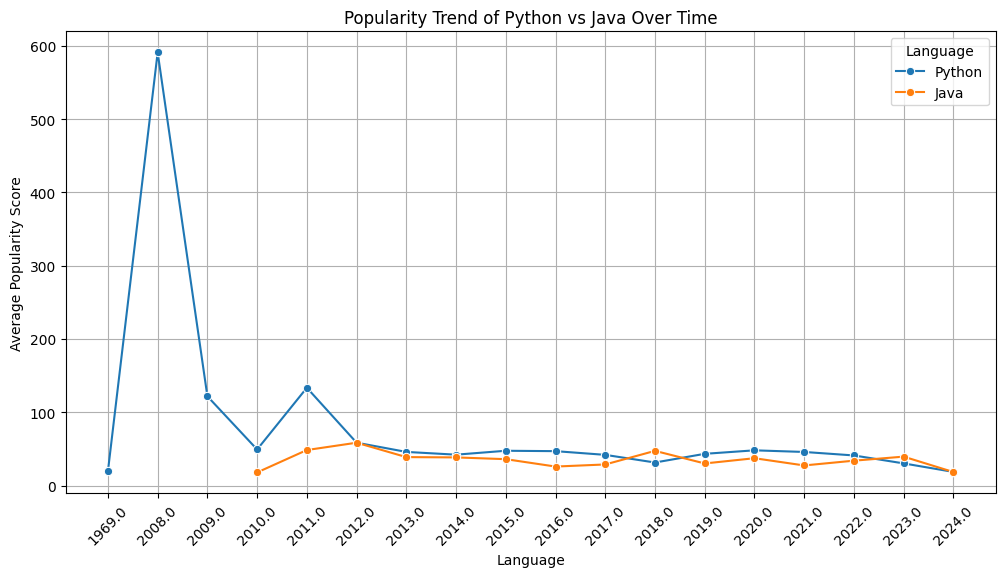

In [50]:
# step 8: visualization of the popularity trend based on joining year

#convert joining_year to categorical variable for a proper spacing
popularity_trend['joining_year'] = popularity_trend['joining_year'].astype(str)

#Replot
plt.figure(figsize=(12, 6))

sns.lineplot(x='joining_year',y='popularity_score',hue='language',data=popularity_trend,marker='o')
           
plt.title("Popularity Trend of Python vs Java Over Time")
plt.xlabel("Language")
plt.ylabel("Average Popularity Score")        
plt.xticks(rotation=45)            # rotate for  better readability
plt.grid(True)             
plt.legend(title="Language")
plt.show()             